## Reconnaissance de motifs semi-supervisée

Explorons maintenant deux tâches de classification plus élaborées, qui montrent tout l'intérêt de combiner raisonnement logique et apprentissage automatique.

Ces tâches consistent à prédire la somme de deux nombres donnés en entrée sous forme d'images. On dispose des images de ces nombres, mais on ne connaît pas leur classe, c'est-à-dire leur étiquette individuelle. La seule information disponible est leur somme. La première tâche, plus simple, consiste à prédire la somme de deux nombres à un seul chiffre. La seconde, plus complexe, consiste à prédire la somme de deux nombres à plusieurs chiffres.

Pour construire notre jeu de données, on utilise le célèbre jeu MNIST, qui contient des chiffres manuscrits étiquetés.

**Addition de chiffres simples.** Considérons le prédicat $addition(X,Y,n)$, où $X$ et $Y$ sont des images de chiffres, et $n$ un nombre naturel correspondant à leur somme. Ce prédicat doit renvoyer une estimation de la validité de cette addition. Par exemple, $addition(img(8),img(3),11)$ est une addition valide, tandis que $addition(img(3),img(3),5)$ ne l'est pas. Ici, $img(x)$ désigne "une image du chiffre $x$", à ne pas confondre avec une fonction logique.

**Addition de nombres à plusieurs chiffres.** L'expérience s'étend à des nombres comportant plusieurs chiffres. Considérons le prédicat $addition([img(X_1),img(X_2)],[img(Y_1),img(Y_2)],n)$, où les deux listes représentent deux nombres à deux chiffres, et $n$ leur somme. Par exemple, $addition([img(2),img(0)],[img(1),img(7)],37)$ est valide, tandis que $addition([img(5),img(4)],[img(9),img(0)],50)$ ne l'est pas.

Une approche neuro-symbolique naturelle consiste à chercher à apprendre un classifieur de chiffre unique, et à tirer parti des connaissances déjà disponibles sur les propriétés de l'addition. Supposons qu'un prédicat $digit(x,d)$ donne la vraisemblance qu'une image $x$ représente le chiffre $d$. Une définition de $addition(img(3),img(8),11)$ en LTN serait :

$$\exists d_1,d_2 : d_1+d_2=11\ \ \big(digit(img(3),d_1)\land digit(img(8),d_2)\big)$$

Cette tâche est rendue plus difficile par le fait qu'aucune étiquette n'est fournie pour les images de chiffres individuelles pendant l'entraînement. L'entraînement porte plutôt sur des paires d'images, pour lesquelles seule l'étiquette du résultat est disponible, c'est-à-dire la somme des étiquettes individuelles. Le classifieur de chiffre n'est donc jamais entraîné directement sur sa propre tâche : sa sortie reste une information latente, exploitée uniquement par la logique. Cela ne pose toutefois aucun problème pour un système neuro-symbolique de bout en bout comme LTN, dans lequel le gradient peut se propager à travers toute la structure logique.

Commençons par présenter une théorie LTN permettant d'apprendre le prédicat $digit$. La spécification ci-dessous concerne le cas de l'addition à un seul chiffre, mais s'étend facilement au cas à plusieurs chiffres.

**Domaines :**
- $images$, désignant les images de chiffres MNIST ;
- $results$, désignant les entiers correspondant aux résultats des additions ;
- $digits$, désignant les chiffres de 0 à 9.

**Variables :**
- $x,y$ parcourant les images MNIST ;
- $n$ pour les étiquettes, c'est-à-dire les résultats des additions ;
- $d_1,d_2$ parcourant les chiffres ;
- $D(x)=D(y)=images$ ;
- $D(n)=results$ ;
- $D(d_1)=D(d_2)=digits$.

**Prédicats :**
- $digit(x,d)$, le classifieur de chiffre unique, où $d$ désigne une constante ou une variable représentant un chiffre. Ce classifieur doit renvoyer la probabilité que l'image $x$ représente le chiffre $d$ ;
- $D_{in}(digit)=images,digits$.

**Axiomes :**

Addition à un chiffre :

$$\forall\,\text{Diag}(x,y,n)\ \ \Big(\exists d_1,d_2 : d_1+d_2=n\ \ \big(digit(x,d_1)\land digit(y,d_2)\big)\Big)$$

Addition à plusieurs chiffres :

$$\forall\,\text{Diag}(x_1,x_2,y_1,y_2,n)\ \ \Big(\exists d_1,d_2,d_3,d_4 : 10d_1+d_2+10d_3+d_4=n\ \ \big(digit(x_1,d_1)\land digit(x_2,d_2)\land digit(y_1,d_3)\land digit(y_2,d_4)\big)\Big)$$

L'usage de $\text{Diag}$ garantit que, lors du grounding de $x,y,n$ avec trois séquences de valeurs, les $i$-èmes exemples de chaque variable se correspondent : $(\mathcal{G}(x)_i,\mathcal{G}(y)_i,\mathcal{G}(n)_i)$ forme un triplet issu de notre jeu de données d'additions valides. Grâce à la quantification diagonale, LTN agrège les paires d'images avec leur résultat correspondant, plutôt que n'importe quelle combinaison entre images et résultats.

On remarque également l'usage de la quantification gardée : en ne quantifiant que sur les "étiquettes intermédiaires" (non fournies pendant l'entraînement) dont la somme peut correspondre à l'étiquette du résultat (elle, fournie), on injecte directement de l'information symbolique dans le système.

**Grounding :**
- $\mathcal{G}(images)=[0,1]^{28\times28\times1}$ : les images MNIST font 28 par 28 pixels, en niveaux de gris (un seul canal). Les valeurs de pixels, initialement de 0 à 255, sont ramenées à l'intervalle $[0,1]$ ;
- $\mathcal{G}(results)=\mathbb{N}$ ;
- $\mathcal{G}(digits)=\{0,1,\dots,9\}$ ;
- $\mathcal{G}(x)\in[0,1]^{m\times28\times28\times1}$, $\mathcal{G}(y)\in[0,1]^{m\times28\times28\times1}$, $\mathcal{G}(n)\in\mathbb{N}^m$ : on utilise le même nombre $m$ d'exemples pour chacune de ces variables, puisqu'elles doivent se correspondre une à une du fait de l'usage de $\text{Diag}$ ;
- $\mathcal{G}(d_1)=\mathcal{G}(d_2)=\langle0,1,\dots,9\rangle$ ;
- $\mathcal{G}(digit\mid\theta):x,d\mapsto\text{onehot}(d)^\top\cdot\text{softmax}(\text{CNN}_\theta(x))$, où $\text{CNN}$ est un réseau de neurones convolutif à 10 neurones de sortie, un par classe. Contrairement aux exemples précédents, $d$ est ici un entier brut ; $\text{onehot}(d)$ le convertit en vecteur one-hot au moment de l'évaluation.

### Jeu de données

Importons et construisons maintenant le jeu de données.

Le jeu MNIST contient 70000 images, réparties en 60000 exemples d'entraînement et 10000 de test. Pour notre tâche, il faut construire un jeu de données ad hoc à partir de MNIST.

Pour le cas à un seul chiffre, les 30000 premières images de l'ensemble d'entraînement servent d'opérandes gauches pour l'addition, tandis que les 30000 dernières servent d'opérandes droits. La somme des étiquettes des opérandes gauche et droit sert de cible. Le même procédé est répété pour construire le jeu de test.

Pour le cas à plusieurs chiffres, l'ensemble d'entraînement est divisé en quatre groupes de 15000 images. Les deux premiers groupes forment les opérandes gauches des additions, les deux derniers les opérandes droits. La cible est construite de façon similaire au cas précédent.

In [1]:
import torch
import pandas as pd
import torchvision

def get_mnist_dataset_for_digits_addition(single_digit=True):
    """
    Prépare le jeu de données pour l'exemple d'addition de chiffres MNIST (chiffre simple ou multi-chiffres)
    de l'article LTN.

    :param single_digit: indique si le jeu de données doit être généré pour le cas à un seul chiffre
        ou à plusieurs chiffres (voir la spécification ci-dessus pour comprendre la différence entre les deux).
    :return: un couple de deux éléments. Le premier est l'ensemble d'entraînement, le second l'ensemble de test.
        Chacun est une liste contenant :
        1. une liste [operandes_gauches, operandes_droits], où operandes_gauches est une liste d'images MNIST
           utilisées comme opérande gauche de l'addition, et operandes_droits comme opérande droit ;
        2. une liste contenant la somme des étiquettes des images du point 1. L'étiquette de l'opérande gauche
           est ajoutée à celle de l'opérande droit, formant la cible de la tâche d'addition.
    Ceci décrit le résultat pour le cas à un seul chiffre. Dans le cas multi-chiffres, la liste du point 1
    comportera 4 éléments, puisque quatre chiffres interviennent dans chaque addition (deux pour représenter
    le premier opérande, deux pour le second).
    """
    if single_digit:
        n_train_examples = 30000
        n_test_examples = 5000
        n_operands = 2
    else:
        n_train_examples = 15000
        n_test_examples = 2500
        n_operands = 4

    mnist_train = torchvision.datasets.MNIST("./datasets/", train=True, download=True,
                                             transform=torchvision.transforms.ToTensor())
    mnist_test = torchvision.datasets.MNIST("./datasets/", train=False, download=True,
                                            transform=torchvision.transforms.ToTensor())

    train_imgs, train_labels, test_imgs, test_labels = mnist_train.data, mnist_train.targets, \
                                                       mnist_test.data, mnist_test.targets

    train_imgs, test_imgs = train_imgs / 255.0, test_imgs / 255.0

    train_imgs, test_imgs = torch.unsqueeze(train_imgs, 1), torch.unsqueeze(test_imgs, 1)

    imgs_operand_train = [train_imgs[i * n_train_examples:i * n_train_examples + n_train_examples]
                          for i in range(n_operands)]
    labels_operand_train = [train_labels[i * n_train_examples:i * n_train_examples + n_train_examples]
                            for i in range(n_operands)]

    imgs_operand_test = [test_imgs[i * n_test_examples:i * n_test_examples + n_test_examples]
                         for i in range(n_operands)]
    labels_operand_test = [test_labels[i * n_test_examples:i * n_test_examples + n_test_examples]
                           for i in range(n_operands)]

    if single_digit:
        label_addition_train = labels_operand_train[0] + labels_operand_train[1]
        label_addition_test = labels_operand_test[0] + labels_operand_test[1]
    else:
        label_addition_train = 10 * labels_operand_train[0] + labels_operand_train[1] + \
                               10 * labels_operand_train[2] + labels_operand_train[3]

        label_addition_test = 10 * labels_operand_test[0] + labels_operand_test[1] + \
                              10 * labels_operand_test[2] + labels_operand_test[3]

    train_set = [torch.stack(imgs_operand_train, dim=1), label_addition_train]
    test_set = [torch.stack(imgs_operand_test, dim=1), label_addition_test]

    return train_set, test_set

# jeu de données pour un seul chiffre
single_d_train_set, single_d_test_set = get_mnist_dataset_for_digits_addition(single_digit=True)
# jeu de données pour plusieurs chiffres
multi_d_train_set, multi_d_test_set = get_mnist_dataset_for_digits_addition(single_digit=False)

### Comprendre la structure des données

Dans cette tâche, il faut distinguer plusieurs niveaux : **un exemple individuel**, **l'ensemble du dataset** et **un batch**. Un exemple correspond à une opération sur plusieurs images MNIST et possède un seul label représentant le résultat de cette opération. Le dataset regroupe plusieurs exemples, tandis qu'un batch correspond à un sous-ensemble de ces exemples utilisé simultanément par le modèle.

<details>
<summary><strong>Voir l'explication détaillée</strong></summary>

#### 1. Un exemple individuel

Dans le cas d'une addition de deux chiffres, un exemple correspond par exemple à :

$$
3 + 7 = 10
$$

Cet exemple contient donc :

```text
Exemple
├── image du chiffre 3
├── image du chiffre 7
└── label = 10
```

Chaque image MNIST est représentée par un tenseur de forme :

```text
(1, 28, 28)
```

où :

* `1` correspond au nombre de canaux (image en niveaux de gris) ;
* `28` correspond à la hauteur ;
* `28` correspond à la largeur.

Comme un exemple contient **2 images**, les deux images sont regroupées dans un tenseur de forme :

```text
(2, 1, 28, 28)
```

On peut lire ces dimensions ainsi :

```text
(2, 1, 28, 28)
 ↑  ↑   ↑   ↑
 │  │   │   └── largeur de l'image
 │  │   └────── hauteur de l'image
 │  └────────── nombre de canaux
 └───────────── nombre d'images dans l'exemple
```

Autrement dit, un exemple individuel contient :

```text
2 images × (1, 28, 28)
+
1 label scalaire
```

---

#### 2. Plusieurs exemples dans le dataset

Supposons que l'on construise `m = 5` exemples :

```text
Exemple 0 : 3 + 7 = 10
Exemple 1 : 2 + 4 =  6
Exemple 2 : 8 + 1 =  9
Exemple 3 : 5 + 2 =  7
Exemple 4 : 6 + 9 = 15
```

Toutes les images sont regroupées dans un seul tenseur :

```python
images.shape = (5, 2, 1, 28, 28)
```

Il faut distinguer les deux premières dimensions :

```text
(5, 2, 1, 28, 28)
 ↑  ↑
 │  └── nombre d'images par exemple
 └───── nombre d'exemples
```

Le tenseur peut donc être vu comme :

```text
images
│
├── exemple 0
│   ├── image du premier chiffre
│   └── image du deuxième chiffre
│
├── exemple 1
│   ├── image du premier chiffre
│   └── image du deuxième chiffre
│
├── exemple 2
│   ├── image du premier chiffre
│   └── image du deuxième chiffre
│
├── exemple 3
│   ├── image du premier chiffre
│   └── image du deuxième chiffre
│
└── exemple 4
    ├── image du premier chiffre
    └── image du deuxième chiffre
```

Les labels sont stockés séparément :

```python
labels.shape = (5,)
```

Par exemple :

```python
labels = tensor([10, 6, 9, 7, 15])
```

Il existe donc une correspondance directe entre les deux tenseurs :

```text
images[0]  ↔ labels[0]
images[1]  ↔ labels[1]
images[2]  ↔ labels[2]
...
```

Ainsi :

```text
images[0]
```

désigne le premier exemple, c'est-à-dire les deux images correspondant à `3 + 7`, tandis que :

```text
labels[0]
```

désigne le label du même exemple, c'est-à-dire `10`.

---

#### 3. Que contient alors `single_d_train_set` ?

Dans le code :

```python
single_d_train_set = [
    torch.stack(imgs_operand_train, dim=1),
    label_addition_train
]
```

`single_d_train_set` est simplement une **liste Python contenant deux éléments** :

```text
single_d_train_set
│
├── [0] → images
└── [1] → labels
```

On a donc :

```python
single_d_train_set[0].shape = (m, 2, 1, 28, 28)
single_d_train_set[1].shape = (m,)
```

Le premier élément contient toutes les images :

```python
single_d_train_set[0]
```

et le deuxième contient tous les labels :

```python
single_d_train_set[1]
```

---

#### 4. Que signifie `single_d_train_set[0][0]` ?

Il y a ici **deux sélections successives**.

D'abord :

```python
single_d_train_set[0]
```

sélectionne le premier élément de la liste, donc **les images** :

```text
(m, 2, 1, 28, 28)
```

Puis :

```python
single_d_train_set[0][0]
```

sélectionne le premier exemple parmi les `m` exemples.

On obtient alors :

```text
(2, 1, 28, 28)
```

Donc :

```text
single_d_train_set[0]
        │
        │ [0]
        ▼
toutes les images
shape = (m, 2, 1, 28, 28)
        │
        │ [0]
        ▼
premier exemple
shape = (2, 1, 28, 28)
```

Le dernier tenseur contient donc exactement les deux images du premier exemple.

---

#### 5. Et `single_d_train_set[1][0]` ?

Même logique, mais cette fois pour les labels.

```python
single_d_train_set[1]
```

sélectionne les labels :

```text
(m,)
```

Puis :

```python
single_d_train_set[1][0]
```

sélectionne le label du premier exemple.

On obtient donc simplement un scalaire :

```text
10
```

Ainsi :

```python
single_d_train_set[0][0]
```

et

```python
single_d_train_set[1][0]
```

désignent bien le **même exemple** :

```text
[image du 3, image du 7]  →  10
```

---

#### 6. Qu'est-ce qu'un batch ?

Un batch contient plusieurs exemples.

Supposons que :

```python
batch_size = 4
```

Le batch contient alors 4 exemples :

```text
Batch
│
├── Exemple 0
│   ├── image du 3
│   ├── image du 7
│   └── label = 10
│
├── Exemple 1
│   ├── image du 2
│   ├── image du 4
│   └── label = 6
│
├── Exemple 2
│   ├── image du 8
│   ├── image du 1
│   └── label = 9
│
└── Exemple 3
    ├── image du 5
    ├── image du 2
    └── label = 7
```

Le tenseur d'images du batch a alors la forme :

```python
batch_images.shape = (4, 2, 1, 28, 28)
```

et les labels :

```python
batch_labels.shape = (4,)
```

On peut lire :

```text
(4, 2, 1, 28, 28)
 ↑  ↑
 │  └── 2 images par exemple
 └───── 4 exemples dans le batch
```

Ainsi, le premier `4` correspond au **nombre d'exemples du batch**, tandis que le `2` correspond au **nombre d'images dans chaque exemple**.

C'est une distinction essentielle.

---

#### 7. Et si chaque exemple contient 4 images ?

Le principe reste exactement le même.

Supposons maintenant qu'un exemple représente une opération sur quatre chiffres :

$$
a + b + c + d
$$

Chaque exemple contient alors :

```text
4 images
+
1 label
```

Une seule image :

```text
(1, 28, 28)
```

Un exemple :

```text
(4, 1, 28, 28)
```

Un dataset contenant `m` exemples :

```text
(m, 4, 1, 28, 28)
```

Et un batch contenant `B` exemples :

```text
(B, 4, 1, 28, 28)
```

avec les labels :

```text
(B,)
```

---

#### 8. Résumé de la structure

Pour une addition de deux chiffres :

```text
UN EXEMPLE
│
├── 2 images
│   ├── (1, 28, 28)
│   └── (1, 28, 28)
│
└── 1 label
    └── scalaire
```

Plusieurs exemples forment le dataset :

```text
IMAGES
(m, 2, 1, 28, 28)

LABELS
(m,)
```

Un batch est ensuite un groupe de `B` exemples :

```text
IMAGES DU BATCH
(B, 2, 1, 28, 28)

LABELS DU BATCH
(B,)
```

L'idée à retenir est donc :

> **Un exemple = plusieurs images + un seul label représentant le résultat de l'opération sur les étiquettes de ces images.**

> **Un batch = plusieurs exemples regroupés ensemble.**

Le point essentiel est de ne pas confondre :

```text
nombre d'exemples
        ↓
        B

nombre d'images par exemple
        ↓
        2 ou 4
```

Par exemple :

```text
(32, 2, 1, 28, 28)
 ↑   ↑
 │   └── 2 images par exemple
 └────── 32 exemples dans le batch
```

Ici, il y a donc **32 additions**, et chacune de ces additions est représentée par **2 images MNIST**.

</details>


À titre d'illustration, affichons le premier exemple de l'ensemble d'entraînement pour le cas à un seul chiffre. Cela aide à comprendre concrètement comment le jeu de données est construit.

Les opérandes sont affichés dans les images suivantes :


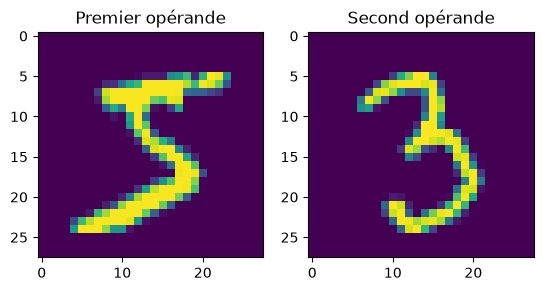

L'étiquette cible (la somme) pour ces opérandes est : 8


In [2]:
import matplotlib.pyplot as plt
first_example_images = single_d_train_set[0][0]
first_example_label = single_d_train_set[1][0]

print("Les opérandes sont affichés dans les images suivantes :")
fig = plt.figure()
ax = fig.add_subplot(1, 2, 1)
imgplot = plt.imshow(first_example_images[0].permute(1, 2, 0))
ax.set_title('Premier opérande')
ax = fig.add_subplot(1, 2, 2)
imgplot = plt.imshow(first_example_images[1].permute(1, 2, 0))
ax.set_title('Second opérande')
plt.show()
print("L'étiquette cible (la somme) pour ces opérandes est : %d" % first_example_label.item())

### Paramétrage LTN

Pour définir notre base de connaissances (les axiomes), il faut définir le prédicat $digit$, les variables $d_1$, $d_2$, $d_3$, $d_4$, les connecteurs, les quantificateurs universel et existentiel, et l'opérateur `SatAgg`.

Pour les connecteurs et quantificateurs, on utilise la configuration produit stable, déjà présentée dans les tutoriels.

Pour le prédicat $digit$, on construit deux modèles. Le premier implémente un CNN qui renvoie les logits pour les dix classes du jeu MNIST, à partir d'une image $x$ donnée en entrée. Le second prend en entrée un exemple étiqueté $(x,d)$, calcule les logits via le premier modèle, puis renvoie la prédiction (via softmax) pour la classe $d$. Autrement dit, il calcule la vraisemblance que l'image $x$ représente le chiffre $d$.

Ces deux modèles séparés sont nécessaires parce qu'on a besoin à la fois des logits et des probabilités : les logits serviront à calculer la précision de classification, tandis que les probabilités seront interprétées comme des degrés de vérité pour calculer le niveau de satisfaction de la base de connaissances.

Les variables $d_1$, $d_2$, $d_3$ et $d_4$ représentent les dix étiquettes de chiffres du jeu MNIST, c'est-à-dire la séquence $\langle0,1,\dots,9\rangle$. Contrairement aux labels one-hot des exemples précédents, ce sont ici des indices entiers bruts.

`SatAgg` est défini à l'aide de l'agrégateur `pMeanError`.

In [3]:
from torch.nn.init import xavier_uniform_, normal_, kaiming_uniform_
import ltn

# on définit les variables
d_1 = ltn.Variable("d_1", torch.tensor(range(10)))
d_2 = ltn.Variable("d_2", torch.tensor(range(10)))
# utilisées seulement dans le cas multi-chiffres
d_3 = ltn.Variable("d_3", torch.tensor(range(10)))
d_4 = ltn.Variable("d_4", torch.tensor(range(10)))

# on définit le prédicat digit
class MNISTConv(torch.nn.Module):
    """
    CNN qui renvoie des embeddings pour des images MNIST.
    Arguments :
        conv_channels_sizes : tuple contenant le nombre de canaux des couches convolutives du modèle. Le premier
        élément doit être le nombre de canaux d'entrée de la première couche, le dernier le nombre de canaux
        de sortie de la dernière couche. Le nombre de couches construites vaut `len(conv_channels_sizes) - 1` ;
        
        kernel_sizes : tuple contenant les tailles des noyaux utilisés dans les couches convolutives ;
        
        linear_layers_sizes : tuple contenant les tailles des couches denses finales de l'architecture. Le premier
        élément doit être le nombre de features en entrée de la première couche dense, le dernier le nombre de
        features en sortie de la dernière. Le nombre de couches construites vaut `len(linear_layers_sizes) - 1`.
    """
    def __init__(self, conv_channels_sizes=(1, 6, 16), kernel_sizes=(5, 5), linear_layers_sizes=(256, 100)):
        super(MNISTConv, self).__init__()
        self.conv_layers = torch.nn.ModuleList([torch.nn.Conv2d(conv_channels_sizes[i - 1], conv_channels_sizes[i],
                                                                kernel_sizes[i - 1])
                                                  for i in range(1, len(conv_channels_sizes))])
        self.elu = torch.nn.ELU()  # activation utilisée partout, comme dans baselines.py (Keras, activation="elu")
        self.maxpool = torch.nn.MaxPool2d((2, 2))
        self.linear_layers = torch.nn.ModuleList([torch.nn.Linear(linear_layers_sizes[i - 1], linear_layers_sizes[i])
                                                  for i in range(1, len(linear_layers_sizes))])

        self.init_weights()

    def forward(self, x):
        for conv in self.conv_layers:
            x = self.elu(conv(x))
            x = self.maxpool(x)
        x = torch.flatten(x, start_dim=1)
        for linear in self.linear_layers:
            x = self.elu(linear(x))
        return x

    def init_weights(self):
        r"""Initialise les poids du réseau.
        Tous les poids (convolutifs et denses) sont initialisés avec :py:func:`torch.nn.init.xavier_uniform_`
        (équivalent de l'initialiseur "glorot_uniform" par défaut de Keras, utilisé dans baselines.py),
        les biais avec :py:func:`torch.nn.init.zeros_`.
        """
        for layer in self.conv_layers:
            xavier_uniform_(layer.weight)
            torch.nn.init.zeros_(layer.bias)

        for layer in self.linear_layers:
            xavier_uniform_(layer.weight)
            torch.nn.init.zeros_(layer.bias)


class SingleDigitClassifier(torch.nn.Module):
    """
    Modèle classifiant une image MNIST de chiffre parmi 10 classes possibles. Il renvoie les logits, une sortie
    non normalisée. Architecture fidèle à baselines.SingleDigit : partie convolutive (MNISTConv, ELU), puis une
    couche dense cachée (ELU), puis la couche de classification finale
    Arguments :
        layers_sizes : tuple contenant les tailles des couches denses finales de l'architecture. Le premier
        élément doit être le nombre de features en entrée de la première couche, le dernier le nombre de
        features en sortie de la dernière. Le nombre de couches construites vaut `len(layers_sizes) - 1`.
    """
    def __init__(self, layers_sizes=(100, 84, 10)):
        super(SingleDigitClassifier, self).__init__()
        self.mnistconv = MNISTConv()  # partie convolutive de l'architecture
        self.elu = torch.nn.ELU()  # activation des couches denses cachées
        self.linear_layers = torch.nn.ModuleList([torch.nn.Linear(layers_sizes[i - 1], layers_sizes[i])
                                                  for i in range(1, len(layers_sizes))])
        self.init_weights()

    def forward(self, x):
        x = self.mnistconv(x)
        for i in range(len(self.linear_layers) - 1):
            x = self.elu(self.linear_layers[i](x))
        return self.linear_layers[-1](x)  # une sigmoïde ou un softmax doit être appliqué sur la dernière couche

    def init_weights(self):
        """Initialise les poids des couches denses du réseau.
        Les poids sont initialisés avec :py:func:`torch.nn.init.xavier_uniform_`,
        les biais avec :py:func:`torch.nn.init.zeros_`.
        """
        for layer in self.linear_layers:
            xavier_uniform_(layer.weight)
            torch.nn.init.zeros_(layer.bias)


class LogitsToPredicate(torch.nn.Module):
    """
    Ce modèle encapsule un modèle de logits, qui calcule les logits des classes pour une image x donnée en entrée.
    L'idée est de garder logits et probabilités séparés : le modèle de logits renvoie les logits pour un exemple,
    tandis que ce modèle-ci renvoie les probabilités à partir de ces logits.

    Concrètement, il prend en entrée une image x et une étiquette de classe d. Il applique le modèle de logits
    à x pour obtenir les logits, puis une fonction softmax pour obtenir les probabilités par classe. Enfin, il
    ne renvoie que la probabilité associée à la classe d, sélectionnée directement par indexation plutôt que
    par produit avec un vecteur one-hot, puisque d est ici un indice entier brut.
    """
    def __init__(self, logits_model):
        super(LogitsToPredicate, self).__init__()
        self.logits_model = logits_model
        self.softmax = torch.nn.Softmax(dim=1)

    def forward(self, x, d):
        logits = self.logits_model(x)
        probs = self.softmax(logits)
        out = torch.gather(probs, 1, d)
        return out

# chiffre simple
cnn_s_d = SingleDigitClassifier()
Digit_s_d = ltn.Predicate(LogitsToPredicate(cnn_s_d)).to(ltn.device)
# chiffres multiples
cnn_m_d = SingleDigitClassifier()
Digit_m_d = ltn.Predicate(LogitsToPredicate(cnn_m_d)).to(ltn.device)

# on définit les connecteurs, quantificateurs, et SatAgg
And = ltn.Connective(ltn.fuzzy_ops.AndProd())
Exists = ltn.Quantifier(ltn.fuzzy_ops.AggregPMean(p=2), quantifier="e")
Forall = ltn.Quantifier(ltn.fuzzy_ops.AggregPMeanError(p=2), quantifier="f")
SatAgg = ltn.fuzzy_ops.SatAgg()


In [4]:
# ===============================================
# BASELINE (CNN classique, sans logique)
# ===============================================

class BaselineNet(torch.nn.Module):
    """
    Réseau "baseline" : encode chaque image opérande avec le MÊME tronc convolutif
    (MNISTConv, poids partagés, architecture siamoise), concatène les embeddings, puis une
    couche dense cachée (ELU) et une couche de classification finale (logits bruts) prédisent
    directement la classe du résultat (la somme) — sans prédicats logiques intermédiaires.
    """
    def __init__(self, n_operands, n_classes, embedding_dim=100, hidden_dim=100):
        super(BaselineNet, self).__init__()
        self.encoder = MNISTConv()  # tronc convolutif partagé entre les opérandes
        self.fc1 = torch.nn.Linear(embedding_dim * n_operands, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, n_classes)
        self.elu = torch.nn.ELU()
        self.init_weights()

    def init_weights(self):
        xavier_uniform_(self.fc1.weight)
        torch.nn.init.zeros_(self.fc1.bias)
        xavier_uniform_(self.fc2.weight)
        torch.nn.init.zeros_(self.fc2.bias)

    def forward(self, images_list):
        embeddings = [self.encoder(img) for img in images_list]
        x = torch.cat(embeddings, dim=1)
        x = self.elu(self.fc1(x))
        return self.fc2(x)  # logits bruts


# baseline pour le cas à un seul chiffre : somme de 2 chiffres -> 19 classes (0 à 18)
baseline_s_d = BaselineNet(n_operands=2, n_classes=19, hidden_dim=84).to(ltn.device)
# baseline pour le cas multi-chiffres : somme de deux nombres à 2 chiffres -> 199 classes (0 à 198)
baseline_m_d = BaselineNet(n_operands=4, n_classes=199, hidden_dim=128).to(ltn.device)

### Utilitaires

Définissons maintenant quelques classes et fonctions utilitaires.

On définit un chargeur de données PyTorch standard, qui prend en entrée le dataset et renvoie un générateur de batchs. On en a besoin de deux instances, une pour l'entraînement, une pour le test. On crée ces chargeurs à la fois pour le cas à un seul chiffre et pour le cas à plusieurs chiffres.

In [5]:
import numpy as np

# chargeur de données PyTorch standard, pour l'entraînement et le test du modèle
class DataLoader(object):
    def __init__(self,
                 fold,
                 batch_size=1,
                 shuffle=True):
        self.fold = fold
        self.batch_size = batch_size
        self.shuffle = shuffle

    def __len__(self):
        return int(np.ceil(self.fold[0].shape[0] / self.batch_size))

    def __iter__(self):
        n = self.fold[0].shape[0]
        idxlist = list(range(n))
        if self.shuffle:
            np.random.shuffle(idxlist)

        for _, start_idx in enumerate(range(0, n, self.batch_size)):
            end_idx = min(start_idx + self.batch_size, n)
            digits = self.fold[0][idxlist[start_idx:end_idx]]
            addition_labels = self.fold[1][idxlist[start_idx:end_idx]]

            yield digits, addition_labels

# création des chargeurs d'entraînement et de test
single_train_loader = DataLoader(single_d_train_set, 32, shuffle=True)
single_test_loader = DataLoader(single_d_test_set, 32, shuffle=False)
multi_d_train_loader = DataLoader(multi_d_train_set, 32, shuffle=True)
multi_d_test_loader = DataLoader(multi_d_test_set, 32, shuffle=False)

### Apprentissage

Notons $D$ l'ensemble complet des exemples du dataset. L'objectif est donné par

$$
\text{SatAgg}_{\phi\in\mathcal{K}}\ \mathcal{G}_{\theta,\,x\leftarrow D}(\phi),
$$

c'est-à-dire que, pour chaque formule $\phi\in\mathcal{K}$, on évalue sa satisfaction sur les exemples $x\in D$ à l'aide du modèle paramétré par $\theta$, puis on agrège l'ensemble de ces valeurs de satisfaction au moyen de $\text{SatAgg}$.


En pratique, l'optimiseur utilise la fonction de perte suivante :

$$L = 1-\text{SatAgg}_{\phi\in\mathcal{K}}\ \mathcal{G}_{\theta,\,x\leftarrow B}(\phi)$$

où $B$ est un mini-batch tiré de $D$, exactement le même principe que dans les exemples précédents.

### Cas à un seul chiffre

On entraîne maintenant notre LTN pour le cas à un seul chiffre, sur 20 epochs, avec l'optimiseur `Adam` et une taille de batch de 32.

L'hyperparamètre $p$ de la quantification existentielle suit une planification progressive, passant de $p=1$ à $p=6$ au fil de l'entraînement. L'idée sous-jacente est qu'en tout début d'entraînement, le classifieur de chiffres est encore proche du hasard : concentrer d'emblée tout le gradient sur la meilleure hypothèse du moment (un $p$ élevé) risquerait de renforcer une combinaison de chiffres incorrecte simplement parce qu'elle a, par hasard, la confiance la plus haute à l'initialisation. Démarrer avec un $p$ faible répartit le gradient plus largement sur toutes les combinaisons plausibles, laissant le bon signal émerger progressivement, avant de resserrer le focus une fois le classifieur devenu plus fiable.

La précision est mesurée en prédisant les valeurs des chiffres à l'aide du prédicat $digit$, puis en calculant la proportion d'exemples pour lesquels l'addition reconstituée est correcte. À chaque epoch, le niveau de satisfaction et la précision sont suivis à la fois sur l'entraînement et sur le test.

La figure suivante montre le graphe de calcul LTN pour le cas à un seul chiffre.

![Graphe de calcul](./images/semisupervised-single.png)

### De la contrainte logique à l'apprentissage des chiffres

Le bloc suivant constitue le cœur de l'apprentissage neuro-symbolique pour l'addition de deux chiffres :

```python
sat_agg = Forall(
    ltn.diag(images_x, images_y, labels_z),
    Exists(
        [d_1, d_2],
        And(
            Digit_s_d(images_x, d_1),
            Digit_s_d(images_y, d_2)
        ),
        cond_vars=[d_1, d_2, labels_z],
        cond_fn=lambda d1, d2, z:
            torch.eq(d1.value + d2.value, z.value),
        p=p
    )
).value
```

Cette expression formalise la connaissance suivante :

$$
\boxed{
\forall (x,y,z),\quad
\exists d_1,d_2:
Digit(x,d_1)\land Digit(y,d_2)\land(d_1+d_2=z)
}
$$

Autrement dit :

> **Pour chaque exemple, il doit exister deux chiffres correspondant aux deux images, tels que leur somme soit égale au résultat observé.**

L'intérêt de cette formulation est que les chiffres individuels des images ne sont pas fournis directement au modèle. Celui-ci apprend donc à les identifier à partir des contraintes logiques imposées sur l'ensemble des exemples.

<details>
<summary><strong>Explication détaillée du fonctionnement</strong></summary>

#### 1. Structure des données

Considérons un batch contenant \(B=2\) exemples :

```text
Exemple 0 : image de 2 + image de 3 → 5
Exemple 1 : image de 1 + image de 4 → 5
```

Les deux images de chaque addition sont séparées dans deux tenseurs :

```python
images_x
images_y
```

et les résultats dans :

```python
labels_z
```

Pour deux exemples :

```text
images_x.shape = (2, 1, 28, 28)
images_y.shape = (2, 1, 28, 28)
labels_z.shape = (2,)
```

La structure est donc :

```text
images_x
├── images_x[0] → image de 2
└── images_x[1] → image de 1

images_y
├── images_y[0] → image de 3
└── images_y[1] → image de 4

labels_z
├── labels_z[0] → 5
└── labels_z[1] → 5
```

La correspondance entre les tenseurs est :

$$
images\_x[i],\ images\_y[i],\ labels\_z[i]
$$

qui constituent ensemble le même exemple.

Un exemple contient donc ici :

$$
\boxed{2\text{ images} + 1\text{ label}}
$$

et un batch contient plusieurs exemples.

---

#### 2. Les variables logiques \(d_1\) et \(d_2\)

Les variables sont définies par :

```python
d_1 = ltn.Variable("d_1", torch.tensor(range(10)))
d_2 = ltn.Variable("d_2", torch.tensor(range(10)))
```

Elles peuvent donc prendre les valeurs :

$$
d_1,d_2\in\{0,1,\ldots,9\}.
$$

Ces variables représentent les **chiffres individuels associés aux deux images**.

Le label \(z\) correspond quant à lui à la somme observée.

Par exemple :

$$
z=5.
$$

Le problème logique consiste alors à trouver deux valeurs \(d_1\) et \(d_2\) telles que :

$$
d_1+d_2=5.
$$

---

#### 3. Le rôle de `ltn.diag(...)`

La formule commence par :

```python
ltn.diag(images_x, images_y, labels_z)
```

Cette construction permet de conserver les associations entre les éléments appartenant au même exemple.

Avec un batch de deux exemples, on travaille donc sur :

```text
(images_x[0], images_y[0], labels_z[0])
(images_x[1], images_y[1], labels_z[1])
```

soit :

```text
(image de 2, image de 3, 5)
(image de 1, image de 4, 5)
```

Les images et les labels ne sont donc pas croisés entre eux.

---

#### 4. Le prédicat `Digit_s_d`

Le prédicat :

```python
Digit_s_d(images_x, d_1)
```

est construit à partir d'un CNN de classification.

Pour une image \(x\), le réseau produit d'abord des logits :

```python
logits = self.logits_model(x)
```

puis un softmax :

```python
probs = self.softmax(logits)
```

On obtient ainsi une distribution de probabilités sur les dix chiffres :

$$
(p_0,p_1,\ldots,p_9),
\qquad
\sum_{d=0}^{9}p_d=1.
$$

Par exemple :

```text
d      0     1     2     3     4     5   ...   9
p_d   0.01  0.02  0.90  0.01  0.01  0.01 ...  ...
```

Si l'image représente réellement un 2, une valeur élevée est attendue pour :

$$
p_2.
$$

Le prédicat `Digit_s_d(x,d)` correspond à la probabilité associée à l'hypothèse \(d\) :

$$
Digit(x,d)=P(d\mid x).
$$

Dans l'implémentation :

```python
out = torch.gather(probs, 1, d)
```

sélectionne directement la probabilité correspondant à l'indice `d`.

Ainsi :

$$
Digit(x,2)=0.90
$$

signifie que le réseau attribue une forte valeur de vérité à l'affirmation :

> l'image \(x\) représente le chiffre 2.

---

#### 5. Toutes les paires de chiffres sont prises en considération

Pour un exemple donné, les variables vérifient :

$$
d_1,d_2\in\{0,\ldots,9\}.
$$

Il existe donc au départ :

$$
10\times10=100
$$

paires possibles :

$$
(0,0),(0,1),\ldots,(9,9).
$$

La formule existentielle va évaluer ces différentes possibilités.

Cependant, toutes ne sont pas compatibles avec le résultat \(z\).

---

#### 6. La contrainte `cond_fn`

La contrainte est donnée par :

```python
cond_vars=[d_1, d_2, labels_z]

cond_fn=lambda d1, d2, z:
    torch.eq(d1.value + d2.value, z.value)
```

Elle vérifie :

$$
d_1+d_2=z.
$$

Supposons :

$$
z=5.
$$

Les seules paires satisfaisant cette contrainte sont :

$$
\boxed{
(0,5),(1,4),(2,3),(3,2),(4,1),(5,0)
}
$$

Par exemple :

$$
2+3=5
$$

est valide, alors que :

$$
2+4=6
$$

est invalide.

La fonction `cond_fn` ne reconnaît donc pas les chiffres à partir des pixels. Elle sert uniquement à déterminer quelles combinaisons de valeurs des variables logiques sont compatibles avec le label.

---

#### 7. Évaluation des combinaisons avec `And`

Pour chaque paire admissible, on calcule :

```python
And(
    Digit_s_d(images_x, d_1),
    Digit_s_d(images_y, d_2)
)
```

Le connecteur utilisé est :

```python
And = ltn.Connective(ltn.fuzzy_ops.AndProd())
```

qui correspond au produit :

$$
And(a,b)=a\times b.
$$

Supposons que le réseau produise, pour l'image du 2 :

$$
P_x(2)=0.90
$$

et, pour l'image du 3 :

$$
P_y(3)=0.85.
$$

Pour la combinaison \((2,3)\), on obtient :

$$
And(0.90,0.85)
=
0.90\times0.85
=
0.765.
$$

Pour les six combinaisons valides, on pourrait par exemple obtenir :

| \((d_1,d_2)\) | \(Digit(x,d_1)\) | \(Digit(y,d_2)\) |  `AndProd` |
| ------------- | ---------------: | ---------------: | ---------: |
| (0,5)         |             0.01 |             0.02 |     0.0002 |
| (1,4)         |             0.02 |             0.01 |     0.0002 |
| **(2,3)**     |         **0.90** |         **0.85** | **0.7650** |
| (3,2)         |             0.01 |             0.03 |     0.0003 |
| (4,1)         |             0.01 |             0.02 |     0.0002 |
| (5,0)         |             0.01 |             0.01 |     0.0001 |

La combinaison \((2,3)\) obtient ici une satisfaction nettement supérieure aux autres.

Cela traduit le fait que :

$$
\text{« l'image }x\text{ est un 2 »}
$$

et :

$$
\text{« l'image }y\text{ est un 3 »}
$$

sont simultanément plausibles.

---

#### 8. Pourquoi plusieurs combinaisons valides ne posent pas problème ?

Pour \(z=5\), plusieurs paires sont mathématiquement correctes :

$$
0+5=5,
\quad
1+4=5,
\quad
2+3=5,
\quad
3+2=5,
\ldots
$$

La contrainte logique ne suffit donc pas, à elle seule, à déterminer les deux chiffres.

C'est le prédicat `Digit_s_d` qui apporte l'information visuelle.

Par exemple, si les images représentent réellement un 2 et un 3, la paire :

$$
(2,3)
$$

obtient une forte valeur tandis que les autres paires obtiennent généralement des valeurs faibles.

La logique ne dit donc pas directement :

$$
d_1=2,\qquad d_2=3.
$$

Elle dit plutôt :

$$
d_1+d_2=5,
$$

puis le CNN détermine quelles valeurs de \(d_1\) et \(d_2\) sont les plus plausibles à partir des images.

---

#### 9. Le rôle de `Exists`

La quantification :

```python
Exists(
    [d_1, d_2],
    And(...),
    cond_vars=[d_1, d_2, labels_z],
    cond_fn=...,
    p=p
)
```

correspond à :

$$
\exists d_1,d_2:
Digit(x,d_1)
\land
Digit(y,d_2)
\land
(d_1+d_2=z).
$$

Elle répond à la question :

> **« Existe-t-il une paire de chiffres suffisamment satisfaisante pour expliquer les deux images et respecter la somme observée ? »**

Les différentes valeurs produites pour les couples admissibles sont donc regroupées en une seule valeur de vérité.

Dans ce code :

```python
Exists = ltn.Quantifier(
    ltn.fuzzy_ops.AggregPMean(p=2),
    quantifier="e"
)
```

l'agrégation utilise `AggregPMean`.

Avec \(p=2\), si les satisfactions sont :

$$
v_1,\ldots,v_n,
$$

on calcule :

$$
M_2(v_1,\ldots,v_n)
=
\left(
\frac{1}{n}
\sum_{i=1}^n v_i^2
\right)^{1/2}.
$$

Ainsi, pour les six combinaisons admissibles :

$$
v_1,\ldots,v_6,
$$

`Exists` produit :

$$
M_2(v_1,\ldots,v_6).
$$


L'agrégation est conçue pour représenter une forme floue de l'existentiel. Elle donne davantage d'importance aux possibilités fortement satisfaites et, lorsque \(p\) augmente, elle se rapproche du comportement d'un maximum.

Le principe recherché est donc :

$$
\exists(d_1,d_2)
$$

est fortement satisfait lorsqu'au moins une possibilité est fortement plausible.

---

#### 10. Exemple numérique du `Exists`

Supposons que les six satisfactions soient :

$$
0.0002,\ 0.0002,\ 0.765,\ 0.0003,\ 0.0002,\ 0.0001.
$$

Alors :

$$
Exists
=
M_2(
0.0002,
0.0002,
0.765,
0.0003,
0.0002,
0.0001
).
$$

On obtient une unique valeur représentant la satisfaction de :

$$
\exists d_1,d_2.
$$

La valeur élevée de la combinaison \((2,3)\) influence donc fortement le résultat final de l'existentiel.

---

#### 11. Comment cette valeur influence les poids du CNN ?

Le point fondamental est que toutes les opérations précédentes sont intégrées dans un graphe de calcul différentiable.

On a la chaîne :

$$
\boxed{
\text{poids du CNN}
\rightarrow
\text{logits}
\rightarrow
\text{softmax}
\rightarrow
Digit
\rightarrow
And
\rightarrow
Exists
}
$$

Le gradient peut donc remonter dans la direction opposée :

$$
\boxed{
Exists
\rightarrow
And
\rightarrow
Digit
\rightarrow
softmax
\rightarrow
logits
\rightarrow
\text{poids du CNN}
}
$$

Prenons la combinaison :

$$
(2,3).
$$

Sa satisfaction est :

$$
v_{2,3}
=
P_x(2)\times P_y(3).
$$

Si :

$$
P_x(2)=a
$$

et :

$$
P_y(3)=b,
$$

alors :

$$
v_{2,3}=ab.
$$

Les dérivées sont :

$$
\frac{\partial v_{2,3}}{\partial a}=b
$$

et :

$$
\frac{\partial v_{2,3}}{\partial b}=a.
$$

Le gradient peut donc agir sur les probabilités associées aux chiffres, puis sur les logits et finalement sur les poids du CNN.

Le réseau est ainsi entraîné à produire des prédictions qui rendent la formule logique de plus en plus satisfaisante.

---

#### 12. Le rôle de `Forall`

La quantification externe est :

```python
Forall(
    ltn.diag(images_x, images_y, labels_z),
    Exists(...)
)
```

Elle signifie :

$$
\forall(x,y,z)
$$

et exprime donc :

> **La propriété doit être satisfaite pour tous les exemples considérés.**

Pour le batch :

```text
Exemple 0 → (image 2, image 3, 5)
Exemple 1 → (image 1, image 4, 5)
```

le `Exists` produit une valeur de satisfaction pour chaque exemple :

$$
E_0,\qquad E_1.
$$

Puis `Forall` agrège ces satisfactions en une valeur globale.

Dans le code :

```python
Forall = ltn.Quantifier(
    ltn.fuzzy_ops.AggregPMeanError(p=2),
    quantifier="f"
)
```

le quantificateur universel repose sur `AggregPMeanError`.

Avec ce dernier, un exemple très mal satisfait pénalise la satisfaction globale davantage qu'un exemple presque parfaitement satisfait.

On obtient donc une valeur représentant la satisfaction de la formule sur l'ensemble des exemples du batch.

---

#### 13. La formule complète

L'expression entière :

```python
Forall(
    ltn.diag(images_x, images_y, labels_z),
    Exists(...)
)
```

correspond essentiellement à :

$$
\boxed{
\forall (x,y,z),\;
\exists d_1,d_2:
Digit(x,d_1)
\land
Digit(y,d_2)
\land
(d_1+d_2=z)
}
$$

Elle peut se lire :

> **Pour chaque exemple, il existe une paire de chiffres correspondant aux deux images et dont la somme est égale au résultat observé.**

Le rôle de chaque élément est alors clairement séparé :

$$
\boxed{
\begin{array}{ll}
Digit & : \text{reconnaissance probabiliste des chiffres}\\[2mm]
cond\_fn & : \text{contrainte mathématique }d_1+d_2=z\\[2mm]
And & : \text{compatibilité simultanée des deux images}\\[2mm]
Exists & : \text{agrégation des différentes explications possibles}\\[2mm]
Forall & : \text{agrégation sur les exemples}
\end{array}
}
$$

---

#### 14. Comment les chiffres individuels sont finalement appris

Un exemple isolé comme :

$$
2+3=5
$$

ne permet pas de déterminer de manière unique les deux chiffres, car plusieurs couples satisfont la somme :

$$
(0,5),(1,4),(2,3),(3,2),(4,1),(5,0).
$$

L'information nécessaire vient donc de l'ensemble des exemples.

Une même image ou des images présentant les mêmes caractéristiques visuelles peuvent apparaître dans différentes additions :

$$
2+3=5,
$$

$$
2+4=6,
$$

$$
2+1=3,
$$

$$
2+5=7,
$$

etc.

Pour toutes ces observations, l'attribution :

$$
d=2
$$

reste cohérente avec les contraintes, alors qu'une attribution incorrecte devient progressivement incompatible avec un nombre croissant d'exemples.

Le même réseau neuronal partage ses paramètres entre tous ces exemples. Les gradients issus de toutes les contraintes sont donc accumulés au cours de l'apprentissage.

Cela pousse progressivement le CNN à produire des distributions telles que :

```text
Image représentant un 2 :

0     1     2     3     4     5   ...   9
.01   .01   .94   .01   .01   .01  ...  ...
```

et donc :

$$
P(2\mid x)\approx1.
$$

Le même mécanisme s'applique aux autres chiffres.

---

#### 15. Pourquoi le réseau peut apprendre sans labels individuels ?

Dans une classification supervisée classique, on fournirait directement :

```text
image du 2 → label 2
image du 3 → label 3
```

et une fonction de perte comparerait directement la prédiction au label.

Ici, les labels individuels des images ne sont pas fournis.

On dispose seulement d'une contrainte globale :

$$
\text{chiffre}_1+\text{chiffre}_2=\text{somme}.
$$

Les chiffres individuels jouent donc le rôle de **variables latentes**.

Le CNN doit apprendre une représentation des images qui permette de satisfaire les contraintes logiques sur l'ensemble du dataset.

C'est précisément le principe de l'apprentissage neuro-symbolique :

$$
\boxed{
\text{le CNN fournit les prédictions}
\quad+\quad
\text{la logique fournit les contraintes}
}
$$

---

#### 16. Vue globale du processus

Le fonctionnement complet peut être résumé ainsi :

```text
                         IMAGES
                           │
                           ▼
                          CNN
                           │
                           ▼
                         LOGITS
                           │
                           ▼
                         SOFTMAX
                           │
                           ▼
              Probabilités des 10 chiffres
                           │
                           ▼
                      Digit_s_d
                           │
                           ▼
              Hypothèses (d₁,d₂) possibles
                           │
                           ▼
               Contrainte d₁ + d₂ = z
                           │
                           ▼
              Combinaisons compatibles
                           │
                           ▼
                            And
                           │
                           ▼
                 Satisfaction de chaque
                   explication possible
                           │
                           ▼
                          Exists
                           │
                           ▼
             Satisfaction d'un exemple
                           │
                           ▼
                          Forall
                           │
                           ▼
             Satisfaction globale du batch
                           │
                           ▼
                        sat_agg
                           │
                           ▼
                         Loss
                           │
                           ▼
                     Backpropagation
                           │
                           ▼
                    Mise à jour du CNN
```

Le cycle est répété sur les différents batches et les différentes époques d'entraînement.

</details>


In [6]:
history_single = {"train_loss": [], "train_sat": [], "train_acc": [],
                   "test_loss": [], "test_sat": [], "test_acc": []}

optimizer = torch.optim.Adam(Digit_s_d.parameters(), lr=0.001)

for epoch in range(20):
    # planification du paramètre p pour le quantificateur existentiel, comme décrit dans l'article LTN
    if epoch in range(0, 4):
        p = 1
    if epoch in range(4, 8):
        p = 2
    if epoch in range(8, 12):
        p = 4
    if epoch in range(12, 20):
        p = 6
    train_loss, test_loss = 0.0, 0.0
    train_sat, test_sat = 0.0, 0.0
    train_acc, test_acc = 0.0, 0.0
    # étape d'entraînement
    cnn_s_d.train()
    for batch_idx, (operand_images, addition_label) in enumerate(single_train_loader):
        optimizer.zero_grad()
        # on groundes les variables avec les données du batch courant
        images_x = ltn.Variable("x", operand_images[:, 0])
        images_y = ltn.Variable("y", operand_images[:, 1])
        labels_z = ltn.Variable("z", addition_label)
        sat_agg = Forall(
            ltn.diag(images_x, images_y, labels_z),
            Exists(
                [d_1, d_2],
                And(Digit_s_d(images_x, d_1), Digit_s_d(images_y, d_2)),
                cond_vars=[d_1, d_2, labels_z],
                cond_fn=lambda d1, d2, z: torch.eq(d1.value + d2.value, z.value),
                p=p
            )).value
        loss = 1. - sat_agg
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_sat += sat_agg.item()
        # calcul de la précision d'entraînement
        predictions_x = torch.argmax(cnn_s_d(operand_images[:, 0].to(ltn.device)), dim=1)
        predictions_y = torch.argmax(cnn_s_d(operand_images[:, 1].to(ltn.device)), dim=1)
        predictions = predictions_x + predictions_y
        train_acc += torch.count_nonzero(torch.eq(addition_label.to(ltn.device), predictions)) / predictions.shape[0]
    train_loss = train_loss / len(single_train_loader)
    train_sat = train_sat / len(single_train_loader)
    train_acc = train_acc / len(single_train_loader)

    # étape de test
    cnn_s_d.eval()
    with torch.no_grad():
        for batch_idx, (operand_images, addition_label) in enumerate(single_test_loader):
            # on groundes les variables avec les données du batch courant
            images_x = ltn.Variable("x", operand_images[:, 0])
            images_y = ltn.Variable("y", operand_images[:, 1])
            labels_z = ltn.Variable("z", addition_label)
            sat_agg = Forall(
                ltn.diag(images_x, images_y, labels_z),
                Exists(
                    [d_1, d_2],
                    And(Digit_s_d(images_x, d_1), Digit_s_d(images_y, d_2)),
                    cond_vars=[d_1, d_2, labels_z],
                    cond_fn=lambda d1, d2, z: torch.eq(d1.value + d2.value, z.value),
                    p=p
                )).value
            loss = 1. - sat_agg
            test_loss += loss.item()
            test_sat += sat_agg.item()
            # calcul de la précision de test
            predictions_x = torch.argmax(cnn_s_d(operand_images[:, 0].to(ltn.device)), dim=1)
            predictions_y = torch.argmax(cnn_s_d(operand_images[:, 1].to(ltn.device)), dim=1)
            predictions = predictions_x + predictions_y
            test_acc += torch.count_nonzero(torch.eq(addition_label.to(ltn.device), predictions)) / predictions.shape[0]
    test_loss = test_loss / len(single_test_loader)
    test_sat = test_sat / len(single_test_loader)
    test_acc = test_acc / len(single_test_loader)

    # enregistrement de l'historique
    history_single["train_loss"].append(float(train_loss))
    history_single["train_sat"].append(float(train_sat))
    history_single["train_acc"].append(float(train_acc))
    history_single["test_loss"].append(float(test_loss))
    history_single["test_sat"].append(float(test_sat))
    history_single["test_acc"].append(float(test_acc))

    # affichage des métriques à chaque epoch
    print(" epoch %d | Train loss %.4f | Train Sat %.4f | Train Acc %.4f | Test loss %.4f | Test Sat %.4f |"
                " Test Acc %.4f " %
          (epoch, train_loss, train_sat, train_acc, test_loss, test_sat, test_acc))


 epoch 0 | Train loss 0.8594 | Train Sat 0.1406 | Train Acc 0.8124 | Test loss 0.8325 | Test Sat 0.1675 | Test Acc 0.9357 
 epoch 1 | Train loss 0.8349 | Train Sat 0.1651 | Train Acc 0.9415 | Test loss 0.8293 | Test Sat 0.1707 | Test Acc 0.9496 
 epoch 2 | Train loss 0.8313 | Train Sat 0.1687 | Train Acc 0.9568 | Test loss 0.8282 | Test Sat 0.1718 | Test Acc 0.9554 
 epoch 3 | Train loss 0.8298 | Train Sat 0.1702 | Train Acc 0.9624 | Test loss 0.8275 | Test Sat 0.1725 | Test Acc 0.9616 
 epoch 4 | Train loss 0.6184 | Train Sat 0.3816 | Train Acc 0.9614 | Test loss 0.6125 | Test Sat 0.3875 | Test Acc 0.9630 
 epoch 5 | Train loss 0.6125 | Train Sat 0.3875 | Train Acc 0.9699 | Test loss 0.6102 | Test Sat 0.3898 | Test Acc 0.9662 
 epoch 6 | Train loss 0.6090 | Train Sat 0.3910 | Train Acc 0.9751 | Test loss 0.6097 | Test Sat 0.3903 | Test Acc 0.9668 
 epoch 7 | Train loss 0.6085 | Train Sat 0.3915 | Train Acc 0.9761 | Test loss 0.6068 | Test Sat 0.3932 | Test Acc 0.9739 
 epoch 8 | Train

### Baseline - cas à un seul chiffre

On entraîne également un réseau "baseline" : un CNN classique, entraîné de façon purement supervisée à prédire directement la somme.


In [7]:
history_baseline_single = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

optimizer_baseline_s = torch.optim.Adam(baseline_s_d.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()

for epoch in range(30):
    train_loss, train_acc = 0.0, 0.0
    # étape d'entraînement
    baseline_s_d.train()
    for batch_idx, (operand_images, addition_label) in enumerate(single_train_loader):
        images_x = operand_images[:, 0].to(ltn.device)
        images_y = operand_images[:, 1].to(ltn.device)
        labels = addition_label.to(ltn.device).long()

        optimizer_baseline_s.zero_grad()
        logits = baseline_s_d([images_x, images_y])
        loss = criterion(logits, labels)
        loss.backward()
        optimizer_baseline_s.step()

        train_loss += loss.item()
        predictions = torch.argmax(logits, dim=1)
        train_acc += torch.count_nonzero(torch.eq(labels, predictions)) / predictions.shape[0]
    train_loss = train_loss / len(single_train_loader)
    train_acc = train_acc / len(single_train_loader)

    # étape de test
    test_loss, test_acc = 0.0, 0.0
    baseline_s_d.eval()
    with torch.no_grad():
        for batch_idx, (operand_images, addition_label) in enumerate(single_test_loader):
            images_x = operand_images[:, 0].to(ltn.device)
            images_y = operand_images[:, 1].to(ltn.device)
            labels = addition_label.to(ltn.device).long()

            logits = baseline_s_d([images_x, images_y])
            loss = criterion(logits, labels)

            test_loss += loss.item()
            predictions = torch.argmax(logits, dim=1)
            test_acc += torch.count_nonzero(torch.eq(labels, predictions)) / predictions.shape[0]
    test_loss = test_loss / len(single_test_loader)
    test_acc = test_acc / len(single_test_loader)

    history_baseline_single["train_loss"].append(float(train_loss))
    history_baseline_single["train_acc"].append(float(train_acc))
    history_baseline_single["test_loss"].append(float(test_loss))
    history_baseline_single["test_acc"].append(float(test_acc))

    print(" epoch %d | [Baseline] Train loss %.4f | Train Acc %.4f | Test loss %.4f | Test Acc %.4f " %
          (epoch, train_loss, train_acc, test_loss, test_acc))


 epoch 0 | [Baseline] Train loss 1.6665 | Train Acc 0.4358 | Test loss 0.5332 | Test Acc 0.8404 
 epoch 1 | [Baseline] Train loss 0.3587 | Train Acc 0.8948 | Test loss 0.2420 | Test Acc 0.9270 
 epoch 2 | [Baseline] Train loss 0.1966 | Train Acc 0.9409 | Test loss 0.1737 | Test Acc 0.9479 
 epoch 3 | [Baseline] Train loss 0.1388 | Train Acc 0.9589 | Test loss 0.1846 | Test Acc 0.9467 
 epoch 4 | [Baseline] Train loss 0.1040 | Train Acc 0.9700 | Test loss 0.1476 | Test Acc 0.9538 
 epoch 5 | [Baseline] Train loss 0.0799 | Train Acc 0.9753 | Test loss 0.1356 | Test Acc 0.9618 
 epoch 6 | [Baseline] Train loss 0.0633 | Train Acc 0.9800 | Test loss 0.1477 | Test Acc 0.9622 
 epoch 7 | [Baseline] Train loss 0.0508 | Train Acc 0.9836 | Test loss 0.1554 | Test Acc 0.9582 
 epoch 8 | [Baseline] Train loss 0.0468 | Train Acc 0.9844 | Test loss 0.1357 | Test Acc 0.9646 
 epoch 9 | [Baseline] Train loss 0.0361 | Train Acc 0.9883 | Test loss 0.1743 | Test Acc 0.9586 
 epoch 10 | [Baseline] Train l

Les variables $x$, $y$ et $n$ sont groundées batch par batch, avec de nouvelles données provenant du chargeur à chaque itération, exactement ce que représente la notation $\mathcal{G}_{x\leftarrow B}(\phi(x))$, où $B$ est le mini-batch fourni par le chargeur.

Contrairement aux exemples précédents, `SatAgg` n'est ici plus utilisé explicitement : la base de connaissances de cet exemple ne contient qu'un seul axiome, la règle d'addition. Puisqu'il n'y a rien d'autre à combiner, `SatAgg` appliqué à une seule valeur de vérité la renverrait inchangée, un calcul redondant. Le résultat de `Forall` sert donc directement de niveau de satisfaction.

Cet exemple montre toute la puissance de l'intégration entre réseaux de neurones et raisonnement logique : aucune étiquette individuelle de chiffre n'est jamais fournie pendant l'entraînement, et pourtant le classifieur apprend à reconnaître les chiffres uniquement à partir de la contrainte logique portant sur leur somme.

### Cas à plusieurs chiffres

Le cas à plusieurs chiffres est identique au cas à un seul chiffre. La seule différence réside dans la façon dont les variables sont groundées, pour tenir compte d'un plus grand nombre de chiffres.

In [8]:
history_multi = {"train_loss": [], "train_sat": [], "train_acc": [],
                  "test_loss": [], "test_sat": [], "test_acc": []}

optimizer = torch.optim.Adam(Digit_m_d.parameters(), lr=0.001)

for epoch in range(20):
    # planification du paramètre p pour le quantificateur existentiel, comme décrit dans l'article LTN
    if epoch in range(0, 4):
        p = 1
    if epoch in range(4, 8):
        p = 2
    if epoch in range(8, 12):
        p = 4
    if epoch in range(12, 20):
        p = 6
    train_loss, test_loss = 0.0, 0.0
    train_sat, test_sat = 0.0, 0.0
    train_acc, test_acc = 0.0, 0.0
    # étape d'entraînement
    cnn_m_d.train()
    for batch_idx, (operand_images, addition_label) in enumerate(multi_d_train_loader):
        optimizer.zero_grad()
        # on groundes les variables avec les données du batch courant
        images_x1 = ltn.Variable("x1", operand_images[:, 0])
        images_x2 = ltn.Variable("x2", operand_images[:, 1])
        images_y1 = ltn.Variable("y1", operand_images[:, 2])
        images_y2 = ltn.Variable("y2", operand_images[:, 3])
        labels_z = ltn.Variable("z", addition_label)
        sat_agg = Forall(
            ltn.diag(images_x1, images_x2, images_y1, images_y2, labels_z),
            Exists(
                [d_1, d_2, d_3, d_4],
                And(
                    And(Digit_m_d(images_x1, d_1), Digit_m_d(images_x2, d_2)),
                    And(Digit_m_d(images_y1, d_3), Digit_m_d(images_y2, d_4))
                ),
                cond_vars=[d_1, d_2, d_3, d_4, labels_z],
                cond_fn=lambda d1, d2, d3, d4, z: torch.eq(10 * d1.value + d2.value + 10 * d3.value + d4.value, z.value),
                p=p
            )).value
        loss = 1. - sat_agg
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_sat += sat_agg.item()
        # calcul de la précision d'entraînement
        predictions_x1 = torch.argmax(cnn_m_d(operand_images[:, 0].to(ltn.device)), dim=1)
        predictions_x2 = torch.argmax(cnn_m_d(operand_images[:, 1].to(ltn.device)), dim=1)
        predictions_y1 = torch.argmax(cnn_m_d(operand_images[:, 2].to(ltn.device)), dim=1)
        predictions_y2 = torch.argmax(cnn_m_d(operand_images[:, 3].to(ltn.device)), dim=1)
        predictions = 10 * predictions_x1 + predictions_x2 + 10 * predictions_y1 + predictions_y2
        train_acc += torch.count_nonzero(torch.eq(addition_label.to(ltn.device), predictions)) / predictions.shape[0]
    train_loss = train_loss / len(multi_d_train_loader)
    train_sat = train_sat / len(multi_d_train_loader)
    train_acc = train_acc / len(multi_d_train_loader)

    # étape de test
    cnn_m_d.eval()
    with torch.no_grad():
        for batch_idx, (operand_images, addition_label) in enumerate(multi_d_test_loader):
            # on groundes les variables avec les données du batch courant
            images_x1 = ltn.Variable("x1", operand_images[:, 0])
            images_x2 = ltn.Variable("x2", operand_images[:, 1])
            images_y1 = ltn.Variable("y1", operand_images[:, 2])
            images_y2 = ltn.Variable("y2", operand_images[:, 3])
            labels_z = ltn.Variable("z", addition_label)
            sat_agg = Forall(
                ltn.diag(images_x1, images_x2, images_y1, images_y2, labels_z),
                Exists(
                    [d_1, d_2, d_3, d_4],
                    And(
                        And(Digit_m_d(images_x1, d_1), Digit_m_d(images_x2, d_2)),
                        And(Digit_m_d(images_y1, d_3), Digit_m_d(images_y2, d_4))
                    ),
                    cond_vars=[d_1, d_2, d_3, d_4, labels_z],
                    cond_fn=lambda d1, d2, d3, d4, z: torch.eq(10 * d1.value + d2.value + 10 * d3.value + d4.value, z.value),
                    p=p
                )).value
            loss = 1. - sat_agg
            test_loss += loss.item()
            test_sat += sat_agg.item()
            # calcul de la précision de test
            predictions_x1 = torch.argmax(cnn_m_d(operand_images[:, 0].to(ltn.device)), dim=1)
            predictions_x2 = torch.argmax(cnn_m_d(operand_images[:, 1].to(ltn.device)), dim=1)
            predictions_y1 = torch.argmax(cnn_m_d(operand_images[:, 2].to(ltn.device)), dim=1)
            predictions_y2 = torch.argmax(cnn_m_d(operand_images[:, 3].to(ltn.device)), dim=1)
            predictions = 10 * predictions_x1 + predictions_x2 + 10 * predictions_y1 + predictions_y2
            test_acc += torch.count_nonzero(torch.eq(addition_label.to(ltn.device), predictions)) / predictions.shape[0]
    test_loss = test_loss / len(multi_d_test_loader)
    test_sat = test_sat / len(multi_d_test_loader)
    test_acc = test_acc / len(multi_d_test_loader)

    # enregistrement de l'historique
    history_multi["train_loss"].append(float(train_loss))
    history_multi["train_sat"].append(float(train_sat))
    history_multi["train_acc"].append(float(train_acc))
    history_multi["test_loss"].append(float(test_loss))
    history_multi["test_sat"].append(float(test_sat))
    history_multi["test_acc"].append(float(test_acc))

    # affichage des métriques à chaque epoch
    print(" epoch %d | Train loss %.4f | Train Sat %.4f | Train Acc %.4f | Test loss %.4f | Test Sat %.4f |"
                " Test Acc %.4f " %
          (epoch, train_loss, train_sat, train_acc, test_loss, test_sat, test_acc))


 epoch 0 | Train loss 0.9897 | Train Sat 0.0103 | Train Acc 0.5497 | Test loss 0.9832 | Test Sat 0.0168 | Test Acc 0.8180 
 epoch 1 | Train loss 0.9833 | Train Sat 0.0167 | Train Acc 0.8576 | Test loss 0.9822 | Test Sat 0.0178 | Test Acc 0.8699 
 epoch 2 | Train loss 0.9824 | Train Sat 0.0176 | Train Acc 0.8962 | Test loss 0.9821 | Test Sat 0.0179 | Test Acc 0.8778 
 epoch 3 | Train loss 0.9826 | Train Sat 0.0174 | Train Acc 0.8917 | Test loss 0.9826 | Test Sat 0.0174 | Test Acc 0.8382 
 epoch 4 | Train loss 0.8840 | Train Sat 0.1160 | Train Acc 0.8997 | Test loss 0.8773 | Test Sat 0.1227 | Test Acc 0.9260 
 epoch 5 | Train loss 0.8785 | Train Sat 0.1215 | Train Acc 0.9329 | Test loss 0.8775 | Test Sat 0.1225 | Test Acc 0.9252 
 epoch 6 | Train loss 0.8764 | Train Sat 0.1236 | Train Acc 0.9444 | Test loss 0.8749 | Test Sat 0.1251 | Test Acc 0.9415 
 epoch 7 | Train loss 0.8757 | Train Sat 0.1243 | Train Acc 0.9489 | Test loss 0.8756 | Test Sat 0.1244 | Test Acc 0.9375 
 epoch 8 | Train

### Baseline (CNN classique) - cas multi-chiffres

Même principe que pour le cas à un seul chiffre, avec 4 opérandes en entrée (les images des deux chiffres de chacun des deux nombres) et 199 classes en sortie (la somme de deux nombres à deux chiffres varie de 0 à 198).


In [9]:
history_baseline_multi = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

optimizer_baseline_m = torch.optim.Adam(baseline_m_d.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()

for epoch in range(30):
    train_loss, train_acc = 0.0, 0.0
    # étape d'entraînement
    baseline_m_d.train()
    for batch_idx, (operand_images, addition_label) in enumerate(multi_d_train_loader):
        images_x1 = operand_images[:, 0].to(ltn.device)
        images_x2 = operand_images[:, 1].to(ltn.device)
        images_y1 = operand_images[:, 2].to(ltn.device)
        images_y2 = operand_images[:, 3].to(ltn.device)
        labels = addition_label.to(ltn.device).long()

        optimizer_baseline_m.zero_grad()
        logits = baseline_m_d([images_x1, images_x2, images_y1, images_y2])
        loss = criterion(logits, labels)
        loss.backward()
        optimizer_baseline_m.step()

        train_loss += loss.item()
        predictions = torch.argmax(logits, dim=1)
        train_acc += torch.count_nonzero(torch.eq(labels, predictions)) / predictions.shape[0]
    train_loss = train_loss / len(multi_d_train_loader)
    train_acc = train_acc / len(multi_d_train_loader)

    # étape de test
    test_loss, test_acc = 0.0, 0.0
    baseline_m_d.eval()
    with torch.no_grad():
        for batch_idx, (operand_images, addition_label) in enumerate(multi_d_test_loader):
            images_x1 = operand_images[:, 0].to(ltn.device)
            images_x2 = operand_images[:, 1].to(ltn.device)
            images_y1 = operand_images[:, 2].to(ltn.device)
            images_y2 = operand_images[:, 3].to(ltn.device)
            labels = addition_label.to(ltn.device).long()

            logits = baseline_m_d([images_x1, images_x2, images_y1, images_y2])
            loss = criterion(logits, labels)

            test_loss += loss.item()
            predictions = torch.argmax(logits, dim=1)
            test_acc += torch.count_nonzero(torch.eq(labels, predictions)) / predictions.shape[0]
    test_loss = test_loss / len(multi_d_test_loader)
    test_acc = test_acc / len(multi_d_test_loader)

    history_baseline_multi["train_loss"].append(float(train_loss))
    history_baseline_multi["train_acc"].append(float(train_acc))
    history_baseline_multi["test_loss"].append(float(test_loss))
    history_baseline_multi["test_acc"].append(float(test_acc))

    print(" epoch %d | [Baseline] Train loss %.4f | Train Acc %.4f | Test loss %.4f | Test Acc %.4f " %
          (epoch, train_loss, train_acc, test_loss, test_acc))


 epoch 0 | [Baseline] Train loss 4.9616 | Train Acc 0.0147 | Test loss 4.6097 | Test Acc 0.0206 
 epoch 1 | [Baseline] Train loss 4.3830 | Train Acc 0.0333 | Test loss 4.3773 | Test Acc 0.0320 
 epoch 2 | [Baseline] Train loss 4.0406 | Train Acc 0.0649 | Test loss 4.2692 | Test Acc 0.0388 
 epoch 3 | [Baseline] Train loss 3.6883 | Train Acc 0.1100 | Test loss 4.1066 | Test Acc 0.0676 
 epoch 4 | [Baseline] Train loss 3.1502 | Train Acc 0.1911 | Test loss 3.7083 | Test Acc 0.1040 
 epoch 5 | [Baseline] Train loss 2.5091 | Train Acc 0.3078 | Test loss 3.3443 | Test Acc 0.1487 
 epoch 6 | [Baseline] Train loss 1.9065 | Train Acc 0.4393 | Test loss 3.0455 | Test Acc 0.2065 
 epoch 7 | [Baseline] Train loss 1.4043 | Train Acc 0.5754 | Test loss 2.8107 | Test Acc 0.2627 
 epoch 8 | [Baseline] Train loss 1.0039 | Train Acc 0.6915 | Test loss 2.7919 | Test Acc 0.3074 
 epoch 9 | [Baseline] Train loss 0.7097 | Train Acc 0.7794 | Test loss 2.7845 | Test Acc 0.3212 
 epoch 10 | [Baseline] Train l

Le connecteur $\land$ est un opérateur binaire, c'est pourquoi il a fallu construire une conjonction imbriquée pour combiner les quatre degrés de vérité associés aux quatre chiffres. La t-norme produit étant associative et commutative ($u\land v=uv$), l'ordre du regroupement n'a aucune incidence sur le résultat final.

### Visualisation

On trace ici, pour chaque tâche, deux graphiques côte à côte : l'accuracy (comparant LTN et le baseline, train et test) et le niveau de satisfaction logique (LTN uniquement, avec les transitions du planning de $p$ annotées, comme dans la figure de l'article). Comme il s'agit d'un seul run (sans agrégation sur plusieurs graines aléatoires par manque de capacité de calcul), il n'y a pas de zone ombrée autour des courbes.


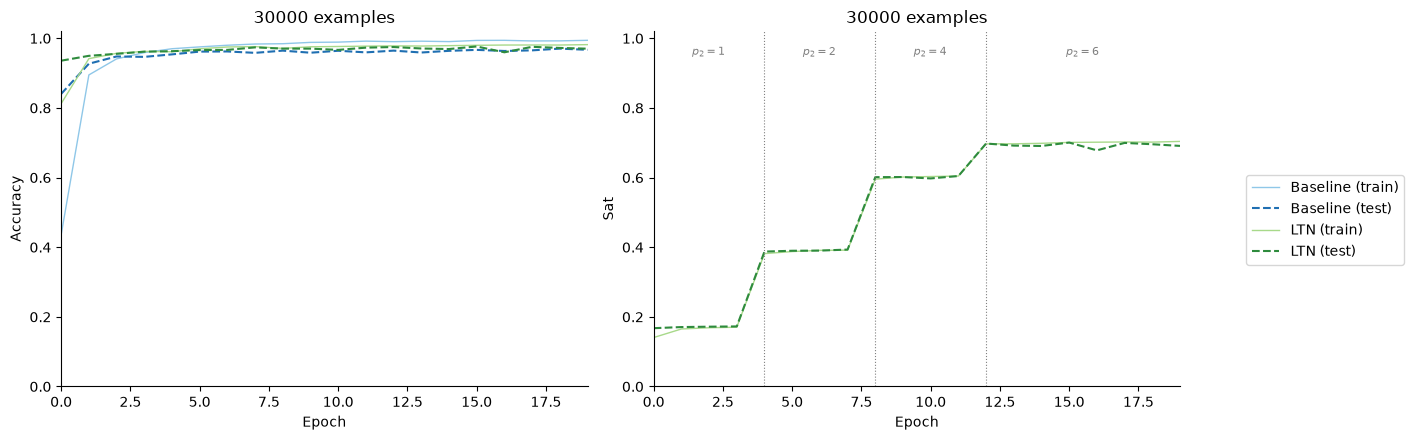

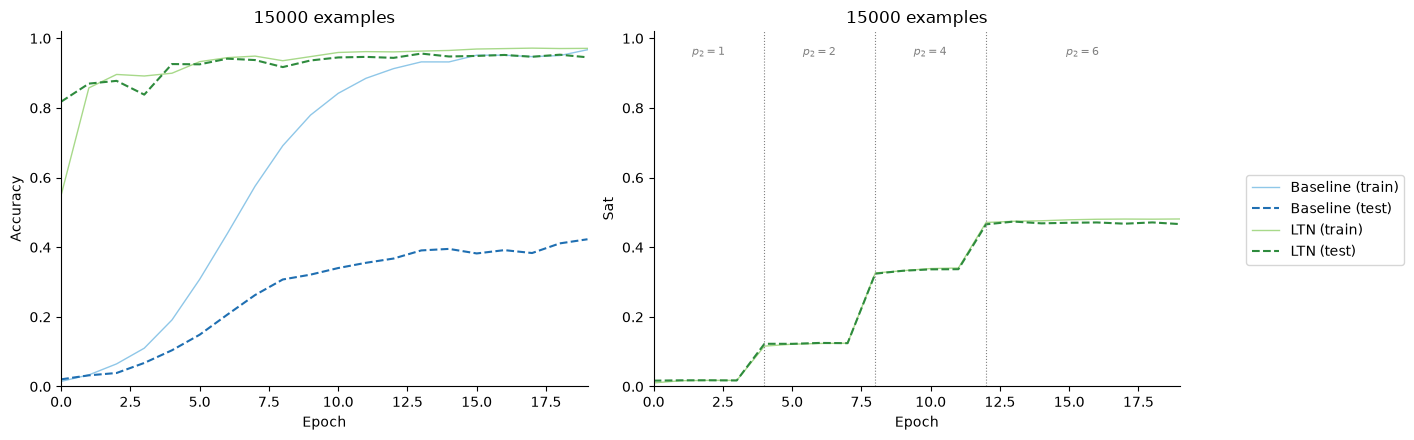

In [13]:
import matplotlib.pyplot as plt

def plot_task_with_baseline(history_ltn, history_baseline, title,
                             p_transitions=(4, 8, 12), p_labels=(1, 2, 4, 6),
                             max_epochs=20):
    epochs = range(max_epochs)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    colors = {
        "baseline_train": "#8fc7e8", "baseline_test": "#1f6fb2",
        "ltn_train": "#a8d98a", "ltn_test": "#2e8b3d",
    }

    # --- Accuracy ---
    ax = axes[0]
    ax.plot(epochs, history_baseline["train_acc"][:max_epochs],
             color=colors["baseline_train"], lw=1, label="Baseline (train)")
    ax.plot(epochs, history_baseline["test_acc"][:max_epochs],
             color=colors["baseline_test"], lw=1.5, ls="--", label="Baseline (test)")
    ax.plot(epochs, history_ltn["train_acc"][:max_epochs],
             color=colors["ltn_train"], lw=1, label="LTN (train)")
    ax.plot(epochs, history_ltn["test_acc"][:max_epochs],
             color=colors["ltn_test"], lw=1.5, ls="--", label="LTN (test)")
    ax.set_ylim(0, 1.02); ax.set_xlim(0, max_epochs - 1)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
    ax.set_title(f"{title} examples")

    # --- Sat ---
    ax = axes[1]
    ax.plot(epochs, history_ltn["train_sat"][:max_epochs],
             color=colors["ltn_train"], lw=1, label="LTN (train)")
    ax.plot(epochs, history_ltn["test_sat"][:max_epochs],
             color=colors["ltn_test"], lw=1.5, ls="--", label="LTN (test)")
    for t in p_transitions:
        ax.axvline(t, color="grey", ls=":", lw=0.8)
    boundaries = [0] + list(p_transitions) + [max_epochs - 1]
    for i, p in enumerate(p_labels):
        mid = (boundaries[i] + boundaries[i + 1]) / 2
        ax.text(mid, 0.95, f"$p_2={p}$", ha="center", fontsize=8, color="grey")
    ax.set_ylim(0, 1.02); ax.set_xlim(0, max_epochs - 1)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Sat")
    ax.set_title(f"{title} examples")

    # Suppression des bordures haut/droite sur les deux axes
    for a in axes:
        a.spines["top"].set_visible(False)
        a.spines["right"].set_visible(False)

    handles, labels_ = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels_, loc="center right", bbox_to_anchor=(1.18, 0.5))
    plt.tight_layout()
    plt.show()

plot_task_with_baseline(history_single, history_baseline_single, "30000")
plot_task_with_baseline(history_multi, history_baseline_multi, "15000")